# CHALLENGE B: WiFi Router Optimization

GOVERNING EQUATION:
 Delta(u) + k(x,y)^2 * u = f(x,y)

 u = complex wave field (WiFi signal amplitude)
 k(x,y) = k0 * n(x,y)  (local wavenumber)
 n = refractive index: 1.0 (air), 2.5+0.5j (walls)
 f = Gaussian source at router position (xr, yr)

BOUNDARY CONDITIONS:
 Outer boundary : first-order absorbing BC: du/dn - i*k0*u = 0
 Internal walls : complex k^2 in wall cells (continuity)

OBJECTIVE:
 Maximise sum of mean|u|^2 over r=5cm circles at 4 rooms,
 subject to: router at least 0.5m from every measurement point.

COMPUTATIONAL STRATEGY:
 The matrix A depends only on geometry, not on router position.
 We factorise A once (LU), then for each candidate position
 only a cheap back-substitution is needed. This makes the
 multi-level optimisation loop feasible.

#### Libraries

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import linalg as sparse_linalg

#### Physical and Numerical Parameters

WAVENUMBER SCALING:
 Real 2.4 GHz -> lambda = 12.5 cm -> need h ~ 1 cm
 -> grid ~ 500k unknowns, infeasible for an optimisation loop.

 Scale by 1/3:
 f_eff = 2.4/3 = 0.8 GHz → lambda = 37.5 cm.
 With h = 5 cm we get ~7.5 points per wavelength, which is
 sufficient to capture interference, wall attenuation, and
 room geometry effects. The optimisation result is qualitatively
 preserved because the dominant physics (proximity to rooms,
 wall crossings, path length) are all correctly modelled.

In [14]:
c_light = 3.0e8        # speed of light [m/s]
freq_eff = 2.4e9 / 3.0      # scaled frequency: 0.8 GHz
k0 = 2.0 * np.pi * freq_eff / c_light

n_air = 1.0 + 0.0j      # refractive index: air
n_wall = 2.5 + 0.5j     # refractive index: walls

A_source = 1.0e4        # Gaussian source amplitude
sigma_source = 0.2      # Gaussian source width [m]

Lx = 10.0       # domain width  [m]
Ly = 8.0        # domain height [m]
h = 0.05        # grid spacing  [m]
wall_t = 0.15       # wall thickness [m]

nx = int(round(Lx / h)) + 1
ny = int(round(Ly / h)) + 1

x_arr = np.linspace(0.0, Lx, nx)
y_arr = np.linspace(0.0, Ly, ny)
X, Y = np.meshgrid(x_arr, y_arr)      # shape (ny, nx)

# Measurement points (Table 1 in assignment)
meas_xy    = [(1.0, 5.0),              # Living Room
              (2.0, 1.0),              # Kitchen
              (9.0, 1.0),              # Bathroom
              (9.0, 7.0)]              # Bedroom 1
meas_names = ["Living Room", "Kitchen", "Bathroom", "Bedroom 1"]
meas_r     = 0.05                      # averaging radius [m]

router_exclusion = 0.5                 # hard constraint [m]
colors_m = ['deepskyblue', 'limegreen', 'tomato', 'orange']

lam = 2.0 * np.pi / k0
print(f"Effective frequency : {freq_eff/1e9:.2f} GHz  (scaled from 2.4 GHz)")
print(f"Wavelength          : {lam*100:.1f} cm")
print(f"Grid spacing        : {h*100:.0f} cm  =  lambda / {lam/h:.1f}")
print(f"Grid size           : {nx} x {ny} = {nx*ny} unknowns")

Effective frequency : 0.80 GHz  (scaled from 2.4 GHz)
Wavelength          : 37.5 cm
Grid spacing        : 5 cm  =  lambda / 7.5
Grid size           : 201 x 161 = 32361 unknowns


#### Floor Plan Wall Mask

Wall segments are read from Figure 5 of the assignment.
Each is an axis-aligned rectangle of uniform thickness 0.15 m.

wall_mask[j,i] = True  -> wall (complex k, attenuation)
wall_mask[j,i] = False -> air  (real k, free propagation)

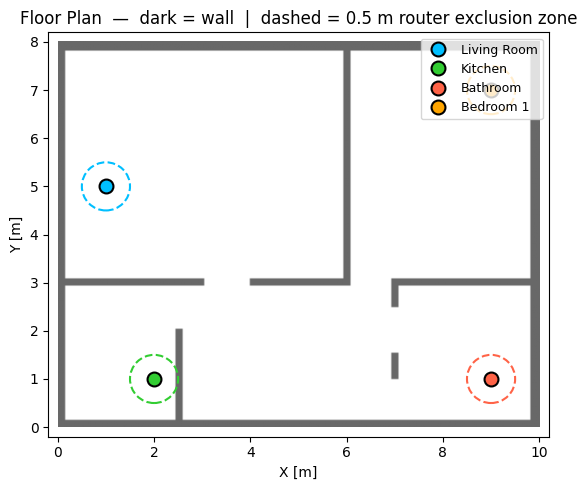

In [15]:
def build_floorplan_mask(X, Y, t, Lx, Ly):
    wall = np.zeros(X.shape, dtype=bool)

    def add(x0, x1, y0, y1):
        wall[(X >= x0) & (X <= x1) & (Y >= y0) & (Y <= y1)] = True

    # Outer walls
    add(0, t, 0, Ly)   # left
    add(Lx-t, Lx, 0, Ly)   # right
    add(0, Lx, 0, t)   # bottom
    add(0, Lx, Ly-t, Ly)   # top

    # Internal walls (from Figure 5)
    add(t, 3.0, 3.0-t/2, 3.0+t/2)   # Kitchen/Living separator
    add(2.5-t/2, 2.5+t/2, t, 2.0)   # Kitchen vertical stub
    add(4.0, 6.0+t/2, 3.0-t/2, 3.0+t/2)   # Hall top wall
    add(6.0-t/2, 6.0+t/2, 3.0-t/2, Ly-t  )   # Living/Bedroom separator
    add(7.0, Lx-t, 3.0-t/2, 3.0+t/2)   # Bathroom top wall
    add(7.0-t/2, 7.0+t/2, 2.5, 3.0+t/2)   # Bathroom upper stub
    add(7.0-t/2, 7.0+t/2, 1.0, 1.5)   # Bathroom lower stub

    return wall


wall_mask = build_floorplan_mask(X, Y, wall_t, Lx, Ly)

# Visualise floor plan to verify geometry
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wall_mask.astype(float), origin='lower',
          extent=[0, Lx, 0, Ly], cmap='Greys', vmin=0, vmax=1.5)
for (xm, ym), name, col in zip(meas_xy, meas_names, colors_m):
    ax.plot(xm, ym, 'o', color=col, ms=10, mec='black', mew=1.5,
            label=name, zorder=5)
    ax.add_patch(plt.Circle((xm, ym), router_exclusion,
                             color=col, fill=False, ls='--', lw=1.5))
ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
ax.set_title('Floor Plan  —  dark = wall  |  dashed = 0.5 m router exclusion zone')
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')
ax.set_xlim(-0.2, Lx + 0.2)
ax.set_ylim(-0.2, Ly + 0.2)
plt.tight_layout()
plt.show()

#### Local k^2(x,y) Field

k(x,y) = k0 * n(x,y)

Air:   k^2 = k0^2                -> real, pure propagation
Wall:  k^2 = k0^2*(2.5+0.5j)^2   -> complex, Im part gives exponential attenuation

This is how internal walls are modelled: no explicit interface
condition is needed. The complex k^2 in wall cells naturally
slows and attenuates the wave, as required by the assignment.

In [16]:

k2_field = np.full(wall_mask.shape, (k0 * n_air )**2, dtype=complex)
k2_field[wall_mask] = (k0 * n_wall)**2

print(f"k^2 in air : {(k0*n_air)**2:.2f}   (real -> propagation only)")
print(f"k^2 in wall: {(k0*n_wall)**2:.2f}  (complex -> attenuation)")

k^2 in air : 280.74+0.00j   (real -> propagation only)
k^2 in wall: 1684.41+701.84j  (complex -> attenuation)


#### Build Sparse Helmholtz Matrix

Discretisation: uniform collocated grid, 5-point FD Laplacian.

Interior point (i,j):
  (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1] - 4*u[i,j]) / h^2 + k^2[i,j] * u[i,j]  =  f[i,j]

Outer boundary: first-order absorbing (e.g. left edge i=0):
  outward normal = -x: (u[1,j]-u[0,j])/h - i*k0*u[0,j] = 0 -> diagonal: -1/h - i*k0,  neighbour: +1/h

Corners: Dirichlet u = 0 (no dominant outward normal).

The resulting matrix A is complex, sparse, and, crucially,
depends ONLY on the geometry (k2_field), NOT on the router.
This is the key that enables the LU factorisation trick.

In [17]:

def build_helmholtz_matrix(nx, ny, h, k2_field, k0):
    h2   = h * h
    rows, cols, vals = [], [], []

    def add(r, c, v):
        rows.append(r); cols.append(c); vals.append(v)

    def idx(i, j):
        return j * nx + i

    for j in range(ny):
        for i in range(nx):
            row = idx(i, j)
            L = (i == 0);    R = (i == nx-1)
            B = (j == 0);    T = (j == ny-1)

            if (L or R) and (B or T):           # corner → Dirichlet
                add(row, row, 1.0+0j)

            elif L:                             # left absorbing BC
                add(row, row, -1/h - 1j*k0)
                add(row, idx(i+1,j), +1/h)

            elif R:                             # right absorbing BC
                add(row, row, +1/h - 1j*k0)
                add(row, idx(i-1,j), -1/h)

            elif B:                             # bottom absorbing BC
                add(row, row, -1/h - 1j*k0)
                add(row, idx(i,j+1), +1/h)

            elif T:                             # top absorbing BC
                add(row, row, +1/h - 1j*k0)
                add(row, idx(i,j-1), -1/h)

            else:                               # interior: 5-pt Laplacian
                add(row, row, -4/h2 + k2_field[j,i])
                add(row, idx(i+1,j), +1/h2)
                add(row, idx(i-1,j), +1/h2)
                add(row, idx(i,j+1), +1/h2)
                add(row, idx(i,j-1), +1/h2)

    return sparse.csr_matrix(
        (np.array(vals, dtype=complex), (rows, cols)),
        shape=(nx*ny, nx*ny))

A_helmholtz = build_helmholtz_matrix(nx, ny, h, k2_field, k0)
print(f"Matrix: {A_helmholtz.shape},  nnz = {A_helmholtz.nnz}")

Matrix: (32361, 32361),  nnz = 159641


#### LU Factorisation (computed once, used many times)

CRITICAL OPTIMISATION:
  A depends only on the room geometry, it is the same for
  every router position. Only the RHS f changes.

  Instead of calling spsolve (full solve) for each candidate:
    spsolve cost: O(N^{3/2}) per candidate

  We factorise once, then back-substitute per candidate:
    splu cost:    O(N^{3/2}) once
    solve cost:   O(N)       per candidate

In [18]:
print("LU factorisation")
A_lu = sparse_linalg.splu(A_helmholtz)

LU factorisation


C:\Users\feder\AppData\Local\Temp\ipykernel_26556\4035101076.py:2: SparseEfficiencyWarning: splu converted its input to CSC format
  A_lu = sparse_linalg.splu(A_helmholtz)


#### Core Functions

In [19]:
def solve_helmholtz(xr, yr):
    """
    Solve (Delta + k^2) u = f for router at (xr, yr).
    Uses pre-factorised LU — only a back-substitution.
    Returns u as 2D array (ny, nx).
    """
    f = A_source * np.exp(
        -((X - xr)**2 + (Y - yr)**2) / (2.0 * sigma_source**2))
    return A_lu.solve(f.flatten()).reshape(ny, nx)


def total_signal(u2d):
    """
    Compute the objective: sum of mean|u|^2 over r=5cm circles
    at all 4 measurement points.
    Returns (total_signal, [signal_per_room]).
    """
    sigs = []
    for (xm, ym) in meas_xy:
        dist2     = (X - xm)**2 + (Y - ym)**2
        in_circle = dist2 <= meas_r**2
        if in_circle.sum() == 0:
            in_circle[np.unravel_index(dist2.argmin(), dist2.shape)] = True
        sigs.append(float(np.mean(np.abs(u2d[in_circle])**2)))
    return float(np.sum(sigs)), sigs


def is_feasible(xr, yr):
    """
    A router position is feasible iff:
      1. Inside domain with margin >= 0.25 m (avoids boundary effects)
      2. Not inside a wall
      3. At least 0.5 m from every measurement point (hard constraint)
    """
    margin = 0.25
    if xr < margin or xr > Lx - margin: return False
    if yr < margin or yr > Ly - margin: return False

    i = int(np.clip(round(xr / h), 0, nx-1))
    j = int(np.clip(round(yr / h), 0, ny-1))
    if wall_mask[j, i]: return False

    for (xm, ym) in meas_xy:
        if np.sqrt((xr-xm)**2 + (yr-ym)**2) < router_exclusion:
            return False
    return True


def grid_search(step, x_lo, x_hi, y_lo, y_hi, label,
                best_sig_floor=-np.inf):
    """
    Evaluate all feasible positions on a regular grid.
    best_sig_floor: carry the previous level's best as a safety floor.
    Returns (best_pos, best_sig, results_list).
    """
    best_pos = None
    best_sig = best_sig_floor
    results  = []

    for xr in np.arange(x_lo, x_hi + step/2, step):
        for yr in np.arange(y_lo, y_hi + step/2, step):
            if not is_feasible(xr, yr):
                continue
            u2d  = solve_helmholtz(xr, yr)
            s, _ = total_signal(u2d)
            results.append((xr, yr, s))
            if s > best_sig:
                best_sig = s
                best_pos = (float(xr), float(yr))

    if best_pos is None:
        raise RuntimeError(f"{label}: no feasible position found in search box.")

    print(f"  {label:<12s} best = ({best_pos[0]:.4f}, {best_pos[1]:.4f})"
          f"  signal = {best_sig:.5e}  ({len(results)} candidates)")
    return best_pos, best_sig, results

#### Three-Level Grid Search (Coarse -> Fine -> Ultra-fine)

SEARCH STRATEGY:

  Level 1, Coarse (step = 0.5 m, full domain):
    Global exploration. Finds the promising region.

  Level 2, Fine (step = 0.1 m, ±1.5 m box around coarse best):
    Refines the candidate. Resolves room-scale structure.

  Level 3, Ultra-fine (step = 0.01 m, ±0.3 m box around fine best):
    Sub-wavelength refinement (0.01 m = lambda/37).
    Captures interference maxima missed by the 0.1 m grid.
    
  Each level passes its best signal as a floor to the next,
  guaranteeing the result never regresses.

In [20]:
print("=" * 55)
print("THREE-LEVEL GRID SEARCH")
print("=" * 55)

# Level 1: Coarse
best_c, sig_c, res_c = grid_search(
    step=0.5, x_lo=0.5, x_hi=Lx-0.5, y_lo=0.5, y_hi=Ly-0.5,
    label="Coarse (0.5m)")

# Level 2: Fine
box2 = 1.5
best_f, sig_f, res_f = grid_search(
    step=0.1,
    x_lo=max(0.25, best_c[0]-box2), x_hi=min(Lx-0.25, best_c[0]+box2),
    y_lo=max(0.25, best_c[1]-box2), y_hi=min(Ly-0.25, best_c[1]+box2),
    label="Fine (0.1m)",
    best_sig_floor=sig_c)

# Level 3: Ultra-fine
box3 = 0.3
best_u, sig_u, res_u = grid_search(
    step=0.01,
    x_lo=max(0.25, best_f[0]-box3), x_hi=min(Lx-0.25, best_f[0]+box3),
    y_lo=max(0.25, best_f[1]-box3), y_hi=min(Ly-0.25, best_f[1]+box3),
    label="Ultra (0.01m)",
    best_sig_floor=sig_f)

print()
print(f"  Improvement coarse -> fine      : "
      f"{10*np.log10(sig_f/sig_c):+.2f} dB")
print(f"  Improvement fine -> ultra-fine  : "
      f"{10*np.log10(sig_u/sig_f):+.2f} dB")
print(f"  Total improvement              : "
      f"{10*np.log10(sig_u/sig_c):+.2f} dB")

THREE-LEVEL GRID SEARCH
  Coarse (0.5m) best = (9.0000, 7.5000)  signal = 4.92861e+01  (248 candidates)
  Fine (0.1m)  best = (9.0000, 7.7000)  signal = 1.12514e+03  (338 candidates)
  Ultra (0.01m) best = (9.0500, 7.7500)  signal = 1.72197e+03  (1759 candidates)

  Improvement coarse -> fine      : +13.58 dB
  Improvement fine -> ultra-fine  : +1.85 dB
  Total improvement              : +15.43 dB


#### Search Maps (one per level)

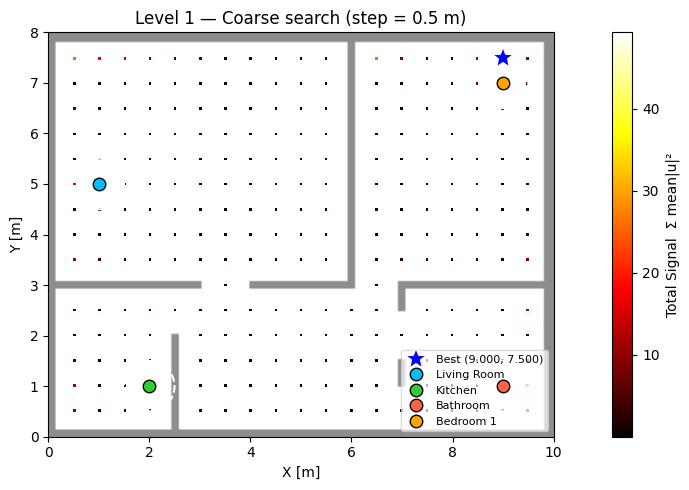

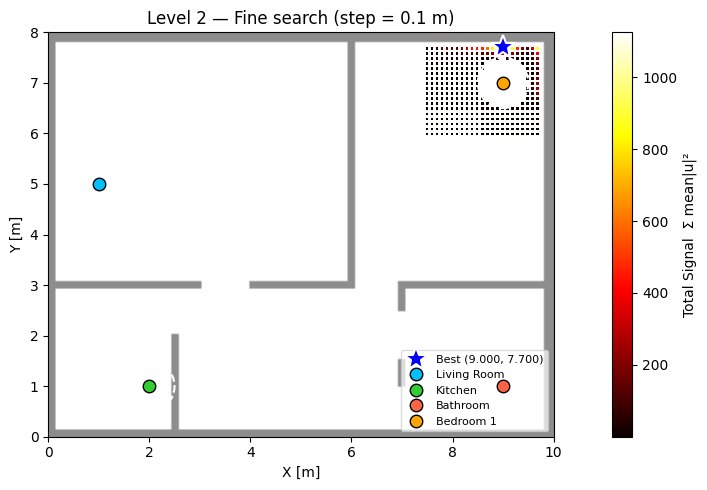

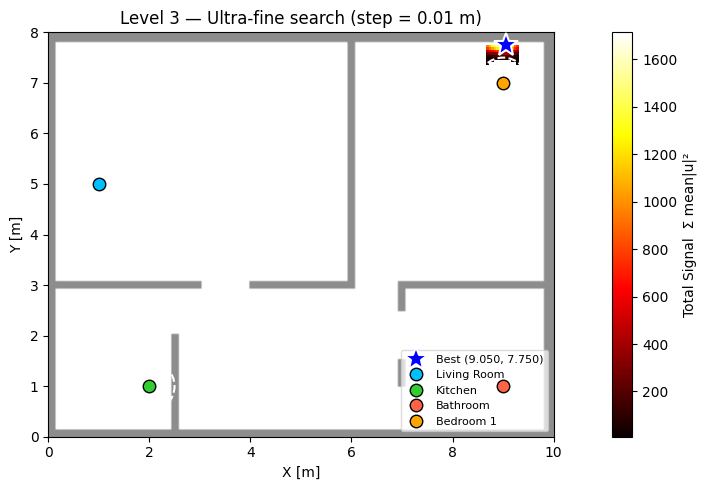

In [21]:
def plot_search_map(results, best_pos, title):
    sig_map = np.full((ny, nx), np.nan)
    for (xr, yr, s) in results:
        i = int(np.clip(round(xr/h), 0, nx-1))
        j = int(np.clip(round(yr/h), 0, ny-1))
        sig_map[j, i] = s

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(sig_map, origin='lower', extent=[0,Lx,0,Ly],
                   cmap='hot', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Total Signal  Σ mean|u|²')
    ax.imshow(np.where(wall_mask, 0.5, np.nan), origin='lower',
              extent=[0,Lx,0,Ly], cmap='gray', alpha=0.45)
    ax.plot(best_pos[0], best_pos[1], 'b*', ms=18, mec='white', mew=1.5,
            label=f'Best ({best_pos[0]:.3f}, {best_pos[1]:.3f})', zorder=7)
    for (xm,ym), name, col in zip(meas_xy, meas_names, colors_m):
        ax.plot(xm, ym, 'o', color=col, ms=9, mec='black',
                label=name, zorder=6)
        ax.add_patch(plt.Circle((xm,ym), router_exclusion,
                                 color='white', fill=False, ls='--', lw=1.5))
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=8, framealpha=0.7)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


plot_search_map(res_c, best_c, "Level 1 — Coarse search (step = 0.5 m)")
plot_search_map(res_f, best_f, "Level 2 — Fine search (step = 0.1 m)")
plot_search_map(res_u, best_u, "Level 3 — Ultra-fine search (step = 0.01 m)")

#### Final Solve and Results

In [22]:
xr_opt = best_u[0]
yr_opt = best_u[1]

u_opt = solve_helmholtz(xr_opt, yr_opt)
sig_opt, sigs_opt = total_signal(u_opt)

print("=" * 55)
print("OPTIMAL ROUTER POSITION")
print("=" * 55)
print(f"  Position     : ({xr_opt:.4f}, {yr_opt:.4f}) m")
print(f"  Total signal : {sig_opt:.5e}")
print()
print("  Per measurement point:")
for name, s in zip(meas_names, sigs_opt):
    dB = 10.0 * np.log10(s / sig_opt) if s > 0 else -np.inf
    print(f"    {name:<14s}: {s:.4e}  ({dB:+.1f} dB relative)")
print()
print("  Feasibility (hard constraint >= 0.5 m):")
for name, (xm, ym) in zip(meas_names, meas_xy):
    d  = np.sqrt((xr_opt-xm)**2 + (yr_opt-ym)**2)
    ok = "" if d >= router_exclusion else "!: VIOLATION"
    print(f"    dist to {name:<14s}: {d:.4f} m  {ok}")

OPTIMAL ROUTER POSITION
  Position     : (9.0500, 7.7500) m
  Total signal : 1.72197e+03

  Per measurement point:
    Living Room   : 7.3705e-01  (-33.7 dB relative)
    Kitchen       : 1.2753e-01  (-41.3 dB relative)
    Bathroom      : 1.3950e+00  (-30.9 dB relative)
    Bedroom 1     : 1.7197e+03  (-0.0 dB relative)

  Feasibility (hard constraint >= 0.5 m):
    dist to Living Room   : 8.5068 m  
    dist to Kitchen       : 9.7604 m  
    dist to Bathroom      : 6.7502 m  
    dist to Bedroom 1     : 0.7517 m  


#### Signal Field at Optimal Position

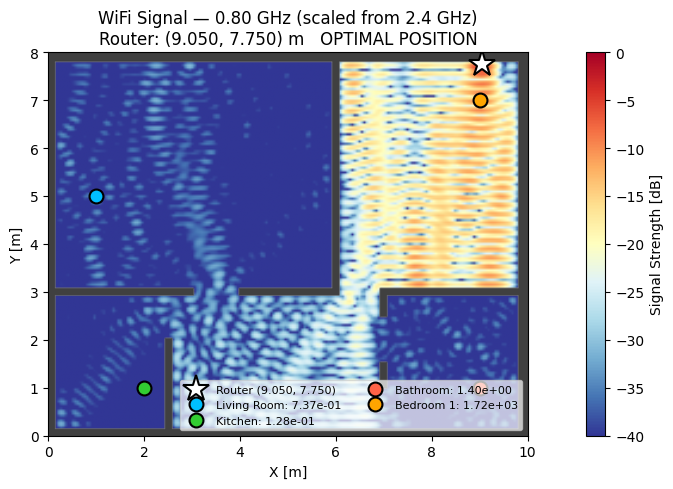

In [23]:
def plot_signal_field(u2d, router_pos, sigs, title_extra=""):
    """Plot WiFi signal strength in dB with walls and measurement points."""
    u_abs  = np.abs(u2d)
    u_max  = np.max(u_abs) if np.max(u_abs) > 0 else 1.0
    sig_dB = 20.0 * np.log10(
        np.where(u_abs > 0, u_abs, 1e-30 * u_max) / u_max)
    sig_dB = np.clip(sig_dB, -40, 0)

    display = sig_dB.copy().astype(float)
    display[wall_mask] = np.nan

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(display, origin='lower', extent=[0,Lx,0,Ly],
                   cmap='RdYlBu_r', vmin=-40, vmax=0,
                   interpolation='bilinear')
    plt.colorbar(im, ax=ax, label='Signal Strength [dB]')
    ax.imshow(np.where(wall_mask, 0.5, np.nan), origin='lower',
              extent=[0,Lx,0,Ly], cmap='gray', alpha=0.75)

    xr, yr = router_pos
    ax.plot(xr, yr, 'w*', ms=20, mec='black', mew=1.5,
            label=f'Router ({xr:.3f}, {yr:.3f})', zorder=6)
    for (xm, ym), name, col, s in zip(meas_xy, meas_names, colors_m, sigs):
        ax.plot(xm, ym, 'o', color=col, ms=10, mec='black', mew=1.5,
                label=f'{name}: {s:.2e}', zorder=5)
        ax.add_patch(plt.Circle((xm,ym), meas_r,
                                 color=col, fill=False, lw=2.5))
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
    ax.set_title(
        f'WiFi Signal — {freq_eff/1e9:.2f} GHz (scaled from 2.4 GHz)\n'
        f'Router: ({xr:.3f}, {yr:.3f}) m   {title_extra}')
    ax.legend(loc='lower right', fontsize=8, framealpha=0.7, ncol=2)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


plot_signal_field(u_opt, (xr_opt, yr_opt), sigs_opt,
                  title_extra="OPTIMAL POSITION")

#### Comparison: Optimal vs House Centre

To demonstrate the value of the optimisation, we compare the
optimal position against a naive baseline: the geometric
centre of the house (5.0, 4.0), which a non-expert might
intuitively choose.


Centre of house (5.0, 4.0) : signal = 6.12385e-02
Optimal (9.050, 7.750)  : signal = 1.72197e+03
Improvement: +44.5 dB  (28119.1x)


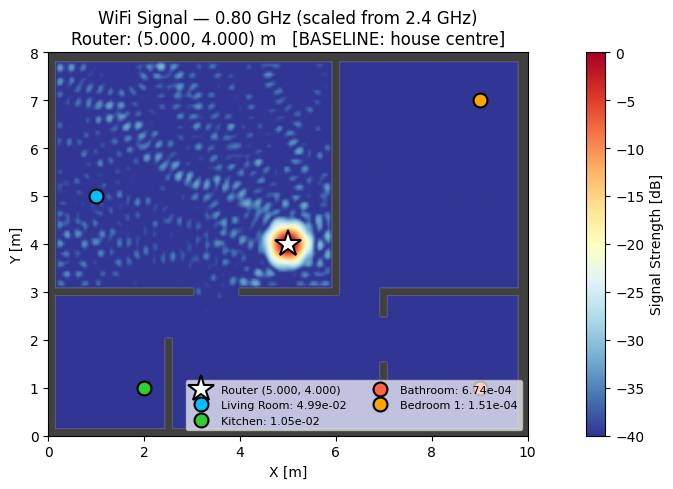

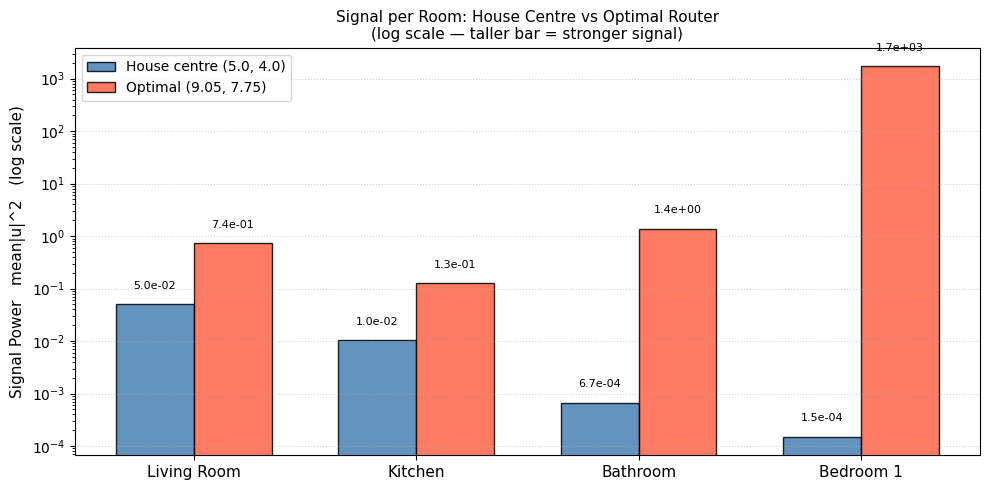

In [24]:
xr_ref, yr_ref    = 5.0, 4.0
u_ref             = solve_helmholtz(xr_ref, yr_ref)
sig_ref, sigs_ref = total_signal(u_ref)

print(f"Centre of house ({xr_ref}, {yr_ref}) : signal = {sig_ref:.5e}")
print(f"Optimal ({xr_opt:.3f}, {yr_opt:.3f})  : signal = {sig_opt:.5e}")
impr = 10.0 * np.log10(sig_opt / sig_ref) if sig_ref > 0 else np.inf
print(f"Improvement: +{impr:.1f} dB  ({sig_opt/sig_ref:.1f}x)")

# Signal field at house centre (for visual comparison)
plot_signal_field(u_ref, (xr_ref, yr_ref), sigs_ref,
                  title_extra="[BASELINE: house centre]")

# Bar chart comparison (log scale — taller = stronger)
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(meas_names))
width = 0.35

ax.bar(x_pos - width/2, sigs_ref, width,
       label=f'House centre ({xr_ref}, {yr_ref})',
       color='steelblue', alpha=0.85, edgecolor='black')
ax.bar(x_pos + width/2, sigs_opt, width,
       label=f'Optimal ({xr_opt:.2f}, {yr_opt:.2f})',
       color='tomato',   alpha=0.85, edgecolor='black')

for bars, sigs in [(ax.containers[0], sigs_ref),
                    (ax.containers[1], sigs_opt)]:
    for bar, v in zip(bars, sigs):
        ax.text(bar.get_x() + bar.get_width()/2, v * 1.8,
                f'{v:.1e}', ha='center', va='bottom', fontsize=8)

ax.set_yscale('log')
ax.set_xticks(x_pos)
ax.set_xticklabels(meas_names, fontsize=11)
ax.set_ylabel('Signal Power   mean|u|^2   (log scale)', fontsize=11)
ax.set_title('Signal per Room: House Centre vs Optimal Router\n'
             '(log scale — taller bar = stronger signal)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()